In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def eda_spambase(csv_file):

    df = pd.read_csv(csv_file)

    target = "class"

    print("=" * 70)
    print("SPAMBASE EXPLORATORY DATA ANALYSIS")
    print("=" * 70)

    print("\nFirst 5 Rows")
    print(df.head())

    print("\nDataset Shape")
    print(df.shape)

    print("\nColumn Names")
    print(df.columns.tolist())

    print("\nTarget Column :", target)

    print("\nDataset Information")
    df.info()

    print("\nStatistical Summary")
    print(df.describe())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows :", df.duplicated().sum())

    if df.duplicated().sum() > 0:

        df = df.drop_duplicates()

        print("Duplicate rows removed.")

    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    numeric_features = [col for col in numerical_cols if col != target]

    print("\nNumber of Features :", len(numeric_features))

    print("\nClass Distribution")
    print(df[target].value_counts())

    print("\n" + "=" * 70)
    print("CLASSIFICATION TASK")
    print("=" * 70)

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=target)
    plt.title("Spam vs Ham Distribution")
    plt.show()

    plt.figure(figsize=(14,10))
    corr = df.corr()
    sns.heatmap(corr, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

    feature_scores = {}

    for feature in numeric_features:

        class_means = df.groupby(target)[feature].mean()

        score = class_means.max() - class_means.min()

        feature_scores[feature] = score

    feature_scores = pd.Series(feature_scores).sort_values(ascending=False)

    print("\nTop 10 Important Features")
    print(feature_scores.head(10))

    top_features = feature_scores.head(5).index.tolist()

    print("\nTop 5 Features")
    print(top_features)

    for feature in top_features:

        plt.figure(figsize=(7,5))
        sns.histplot(
            data=df,
            x=feature,
            hue=target,
            kde=True,
            element="step"
        )
        plt.title(f"Histogram of {feature}")
        plt.show()

    for feature in top_features:

        plt.figure(figsize=(7,5))
        sns.boxplot(
            data=df,
            x=target,
            y=feature
        )
        plt.title(f"{feature} by Class")
        plt.show()

    print("\nGenerating Pair Plot (Top 5 Features)...")

    sns.pairplot(
        df[top_features + [target]],
        hue=target
    )

    plt.show()

    print("\nEDA Completed Successfully.")

    return {
        "df": df,
        "target": target,
        "top_features": top_features,
        "feature_scores": feature_scores
    }

SPAMBASE EXPLORATORY DATA ANALYSIS

First 5 Rows
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00

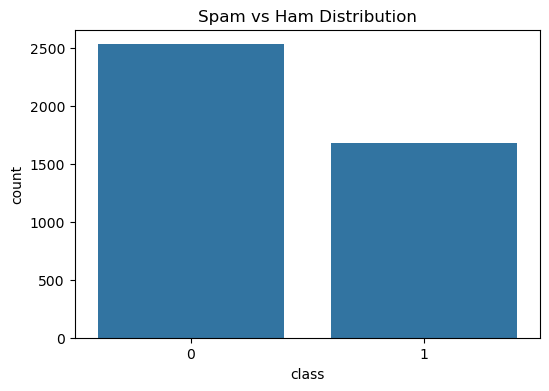

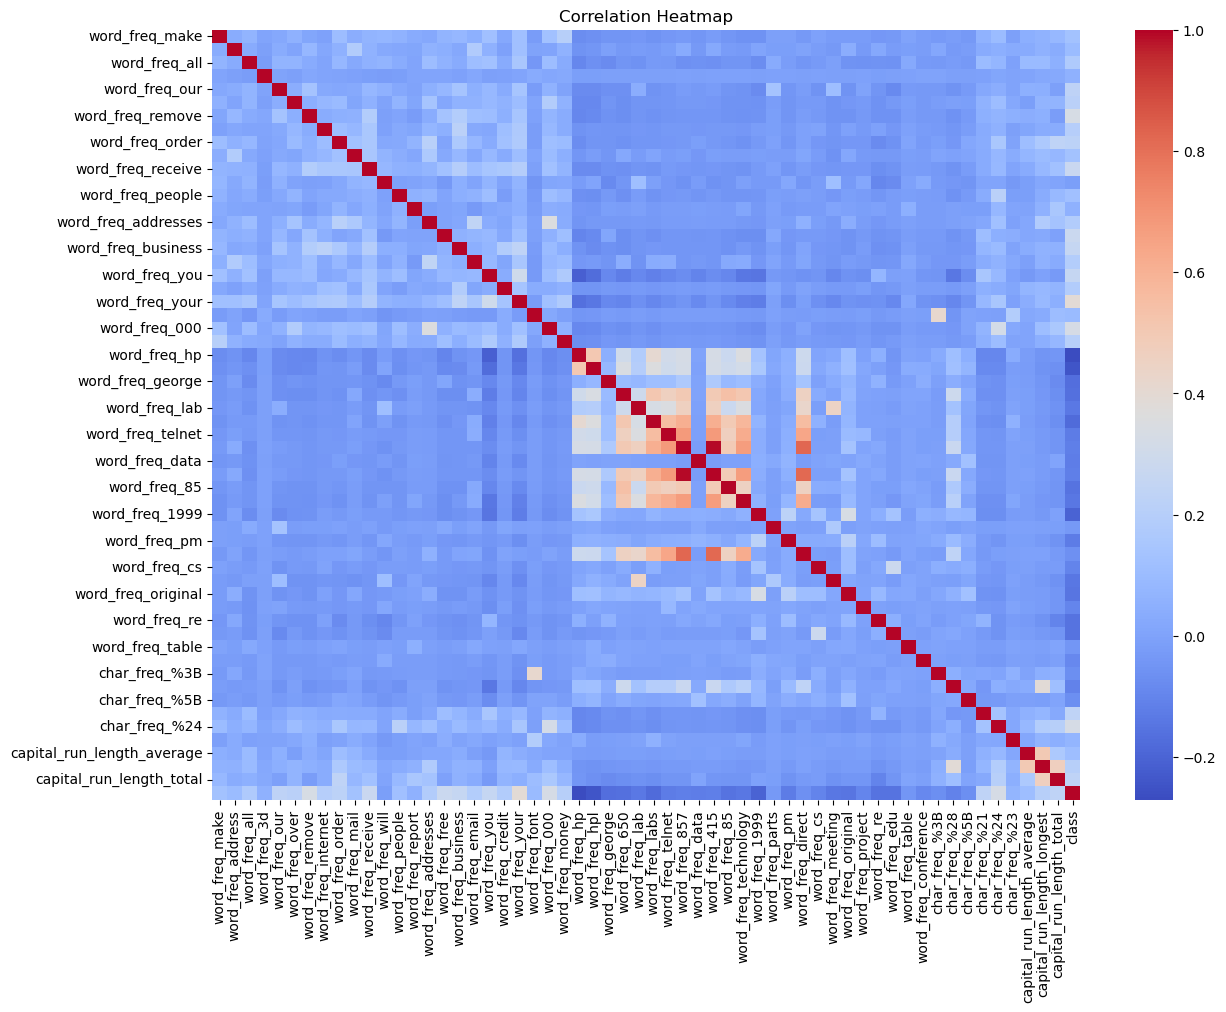


Top 10 Important Features
capital_run_length_total      292.671139
capital_run_length_longest     83.000389
capital_run_length_average      7.464145
word_freq_your                  0.925637
word_freq_you                   0.925506
word_freq_hp                    0.924434
word_freq_george                0.612396
word_freq_free                  0.454799
word_freq_hpl                   0.448254
char_freq_%21                   0.402642
dtype: float64

Top 5 Features
['capital_run_length_total', 'capital_run_length_longest', 'capital_run_length_average', 'word_freq_your', 'word_freq_you']


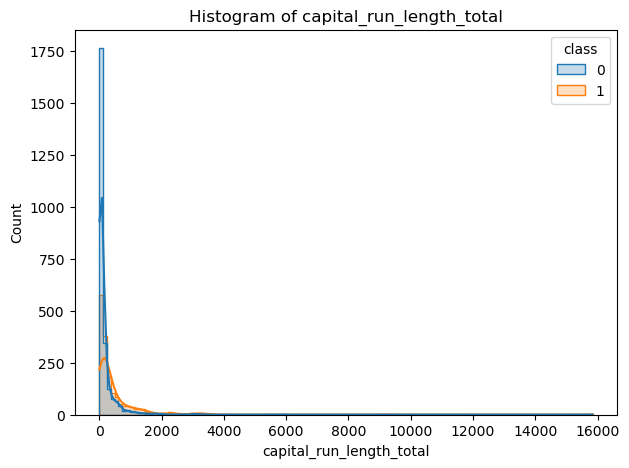

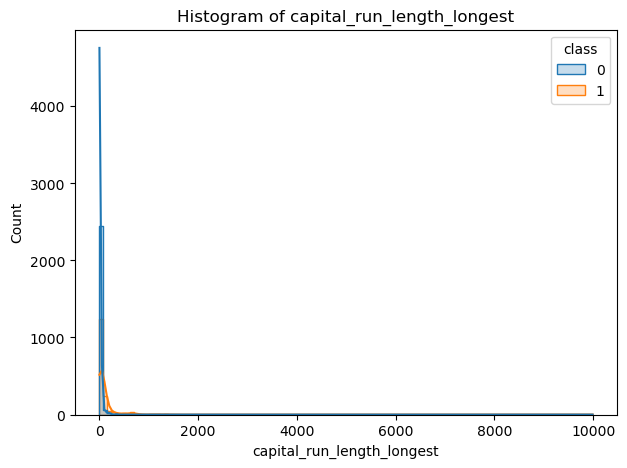

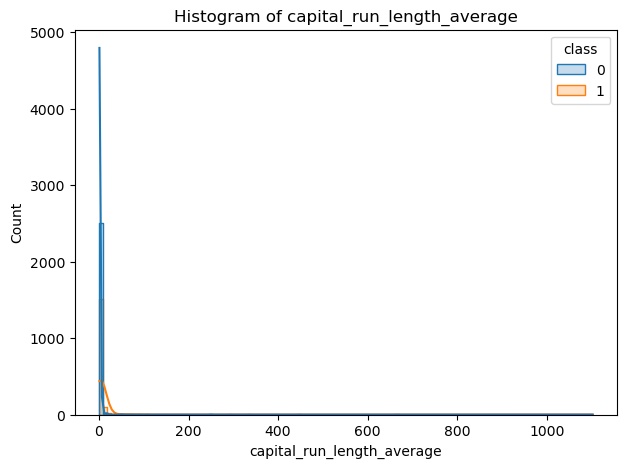

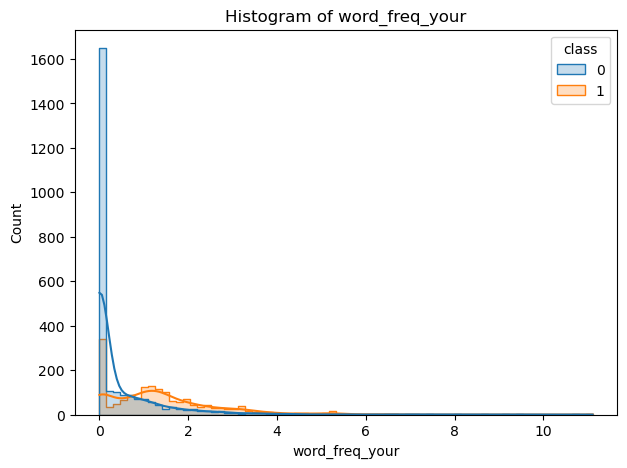

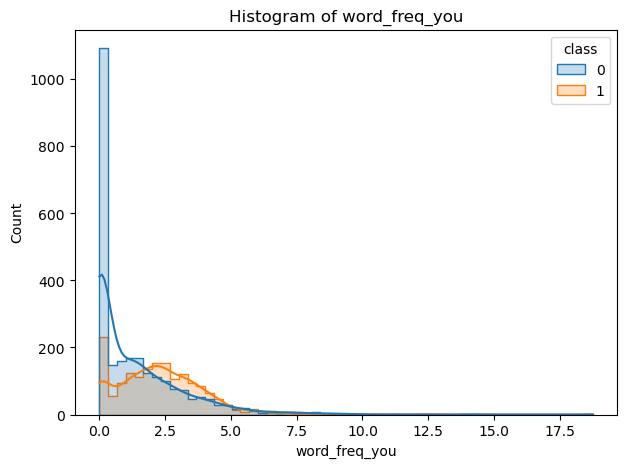

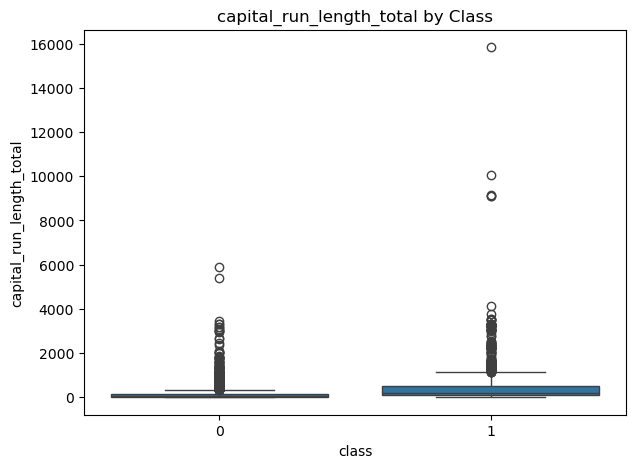

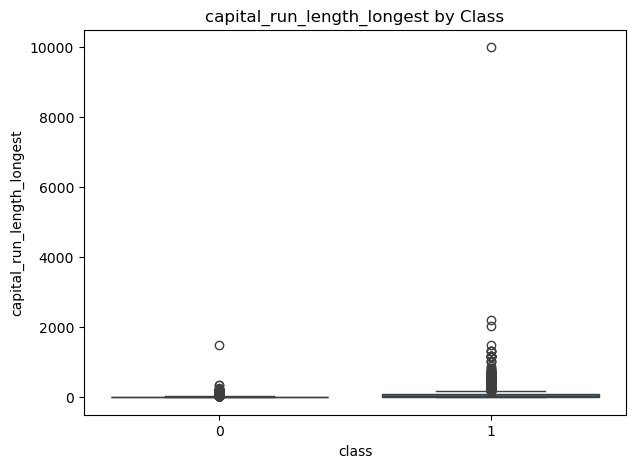

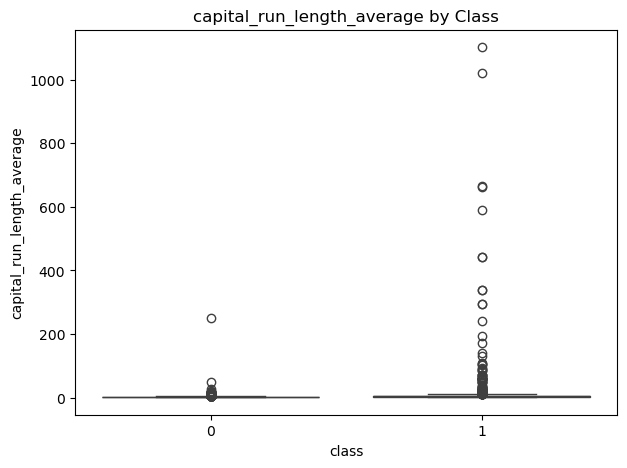

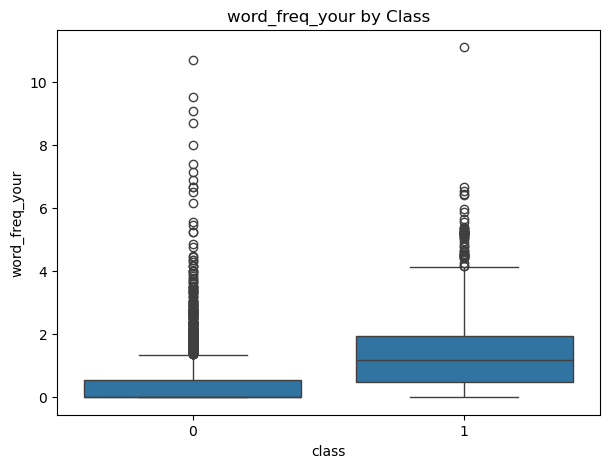

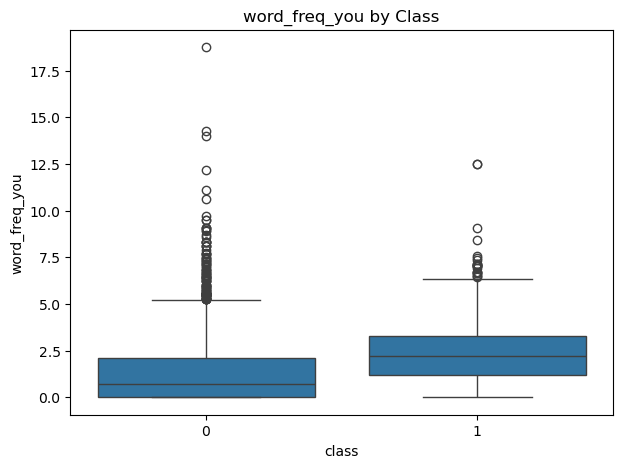


Generating Pair Plot (Top 5 Features)...


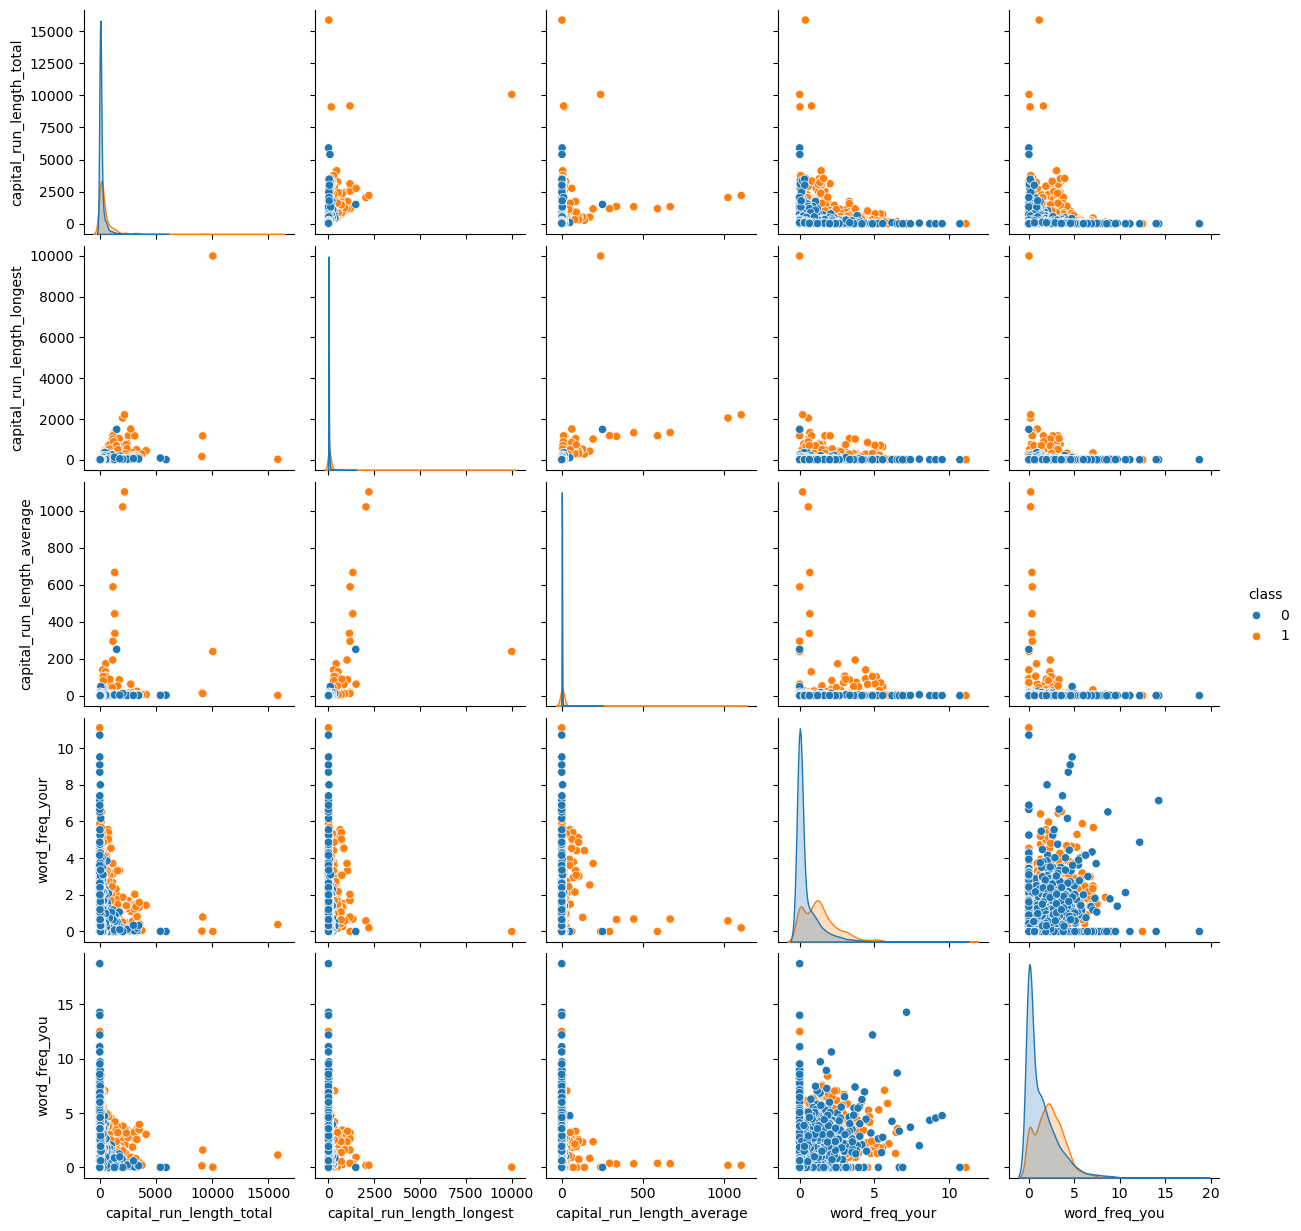


EDA Completed Successfully.


In [2]:
eda = eda_spambase("spambase.csv")

df = eda["df"]
target = eda["target"]
top_features = eda["top_features"]
feature_scores = eda["feature_scores"]

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (3368, 57)
Testing Set  : (842, 57)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print("Feature Normalization Completed.")

print("\nScaled Training Data")
print(X_train_scaled.head())

print("\nScaled Testing Data")
print(X_test_scaled.head())

Feature Normalization Completed.

Scaled Training Data
      word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
478        -0.340998          -0.241548      -0.560617     -0.038852   
1108       -0.340998          -0.241548       0.349622     -0.038852   
1940       -0.340998          -0.241548      -0.560617     -0.038852   
3875       -0.340998          -0.241548      -0.560617     -0.038852   
2199       -0.340998          -0.241548      -0.560617     -0.038852   

      word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
478       -0.465413       -0.162631         -0.296660            0.571078   
1108       0.896764       -0.338357          0.952246           -0.257413   
1940      -0.465413       -0.338357         -0.296660           -0.257413   
3875       0.783249       -0.338357         -0.296660           -0.257413   
2199      -0.465413       -0.338357         -0.296660           -0.257413   

      word_freq_order  word_freq_mail  ...  word_

In [5]:
import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


def evaluate_model(model, X_train, X_test, y_train, y_test):

    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    end_train = time.perf_counter()

    start_predict = time.perf_counter()
    y_pred = model.predict(X_test)
    end_predict = time.perf_counter()

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_score),
    "Training Time": end_train - start_train,
    "Prediction Time": end_predict - start_predict,
    "Confusion Matrix": confusion_matrix(y_test, y_pred),

    "Predictions": y_pred,
    "Scores": y_score,

    "Model": model
}

    return results

In [6]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# Convert frequency features to binary for BernoulliNB
X_train_binary = (X_train > 0).astype(int)
X_test_binary = (X_test > 0).astype(int)

gaussian_results = evaluate_model(
    GaussianNB(),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

multinomial_results = evaluate_model(
    MultinomialNB(),
    X_train,
    X_test,
    y_train,
    y_test
)

bernoulli_results = evaluate_model(
    BernoulliNB(),
    X_train_binary,
    X_test_binary,
    y_train,
    y_test
)

nb_table = pd.DataFrame({

    "Gaussian": [
        gaussian_results["Accuracy"],
        gaussian_results["Precision"],
        gaussian_results["Recall"],
        gaussian_results["F1"],
        gaussian_results["ROC-AUC"]
    ],

    "Multinomial": [
        multinomial_results["Accuracy"],
        multinomial_results["Precision"],
        multinomial_results["Recall"],
        multinomial_results["F1"],
        multinomial_results["ROC-AUC"]
    ],

    "Bernoulli": [
        bernoulli_results["Accuracy"],
        bernoulli_results["Precision"],
        bernoulli_results["Recall"],
        bernoulli_results["F1"],
        bernoulli_results["ROC-AUC"]
    ]

},
index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
])

nb_table

,Gaussian,Multinomial,Bernoulli
Accuracy,0.828979,0.788599,0.894299
Precision,0.714286,0.761589,0.877676
Recall,0.952381,0.684524,0.854167
F1,0.816327,0.721003,0.865762
ROC-AUC,0.947129,0.834245,0.960863


In [7]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11]

knn_results = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    result = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    knn_results.append({
        "k": k,
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1": result["F1"]
    })

knn_table = pd.DataFrame(knn_results)

knn_table

,k,Accuracy,Precision,Recall,F1
0,1,0.906176,0.883582,0.880952,0.882265
1,3,0.909739,0.906250,0.863095,0.884146
2,5,0.913302,0.914826,0.863095,0.888208
3,7,0.904988,0.910256,0.845238,0.876543
4,9,0.907363,0.924342,0.836310,0.878125
5,11,0.908551,0.916399,0.848214,0.880989


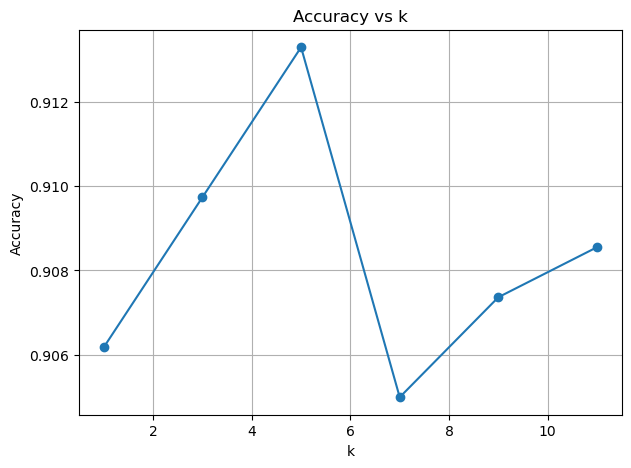

In [8]:
plt.figure(figsize=(7,5))

plt.plot(
    knn_table["k"],
    knn_table["Accuracy"],
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.grid(True)

plt.show()

In [9]:
param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree"]
}

import time

from sklearn.model_selection import GridSearchCV

start = time.perf_counter()

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

grid_time = time.perf_counter() - start

print("Best Parameters :", grid_search.best_params_)
print("Best Accuracy   :", grid_search.best_score_)

from sklearn.model_selection import RandomizedSearchCV

start = time.perf_counter()

random_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_grid,
    n_iter=12,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

random_time = time.perf_counter() - start

print("Best Parameters :", random_search.best_params_)
print("Best Accuracy   :", random_search.best_score_)

Best Parameters : {'algorithm': 'auto', 'n_neighbors': 9, 'weights': 'distance'}
Best Accuracy   : 0.9029095991640249
Best Parameters : {'weights': 'distance', 'n_neighbors': 9, 'algorithm': 'ball_tree'}
Best Accuracy   : 0.9029095991640249


In [10]:
search_table = pd.DataFrame({

    "Parameter": [
        "Best k",
        "Weights",
        "Algorithm",
        "CV Accuracy",
        "Execution Time (s)"
    ],

    "GridSearchCV": [
        grid_search.best_params_["n_neighbors"],
        grid_search.best_params_["weights"],
        grid_search.best_params_["algorithm"],
        round(grid_search.best_score_, 4),
        round(grid_time, 4)
    ],

    "RandomizedSearchCV": [
        random_search.best_params_["n_neighbors"],
        random_search.best_params_["weights"],
        random_search.best_params_["algorithm"],
        round(random_search.best_score_, 4),
        round(random_time, 4)
    ]

})

search_table

,Parameter,GridSearchCV,RandomizedSearchCV
0,Best k,9,9
1,Weights,distance,distance
2,Algorithm,auto,ball_tree
3,CV Accuracy,0.9029,0.9029
4,Execution Time (s),3.3535,0.7691


In [11]:
kd_tree_results = evaluate_model(
    KNeighborsClassifier(
        n_neighbors=grid_search.best_params_["n_neighbors"],
        weights=grid_search.best_params_["weights"],
        algorithm="kd_tree"
    ),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

ball_tree_results = evaluate_model(
    KNeighborsClassifier(
        n_neighbors=grid_search.best_params_["n_neighbors"],
        weights=grid_search.best_params_["weights"],
        algorithm="ball_tree"
    ),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

kd_ball_table = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Training Time (s)",
        "Prediction Time (s)"
    ],

    "KDTree": [
        kd_tree_results["Accuracy"],
        kd_tree_results["Training Time"],
        kd_tree_results["Prediction Time"]
    ],

    "BallTree": [
        ball_tree_results["Accuracy"],
        ball_tree_results["Training Time"],
        ball_tree_results["Prediction Time"]
    ]

})

kd_ball_table

,Metric,KDTree,BallTree
0,Accuracy,0.922803,0.922803
1,Training Time (s),0.014589,0.008249
2,Prediction Time (s),0.099342,0.094587


In [12]:
from sklearn.model_selection import cross_val_score

best_knn = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_["n_neighbors"],
    weights=grid_search.best_params_["weights"],
    algorithm=grid_search.best_params_["algorithm"]
)

nb_scores = cross_val_score(
    GaussianNB(),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

knn_scores = cross_val_score(
    best_knn,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

cv_table = pd.DataFrame({

    "Fold": [1,2,3,4,5,"Average"],

    "Naive Bayes": [
        *nb_scores,
        nb_scores.mean()
    ],

    "Best KNN": [
        *knn_scores,
        knn_scores.mean()
    ]

})

cv_table

,Fold,Naive Bayes,Best KNN
0,1,0.810089,0.905045
1,2,0.810089,0.900593
2,3,0.810089,0.903561
3,4,0.835067,0.897474
4,5,0.833581,0.907875
5,Average,0.819783,0.902910


In [13]:
best_knn_results = evaluate_model(
    grid_search.best_estimator_,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

time_table = pd.DataFrame({

    "Algorithm":[
        "Gaussian NB",
        "Multinomial NB",
        "Bernoulli NB",
        "Best KNN"
    ],

    "Training(s)":[
        gaussian_results["Training Time"],
        multinomial_results["Training Time"],
        bernoulli_results["Training Time"],
        best_knn_results["Training Time"]
    ],

    "Prediction(s)":[
        gaussian_results["Prediction Time"],
        multinomial_results["Prediction Time"],
        bernoulli_results["Prediction Time"],
        best_knn_results["Prediction Time"]
    ]

})

time_table

,Algorithm,Training(s),Prediction(s)
0,Gaussian NB,0.002255,0.000753
1,Multinomial NB,0.001419,0.000555
2,Bernoulli NB,0.002436,0.000842
3,Best KNN,0.002184,0.006734


<Figure size 500x400 with 0 Axes>

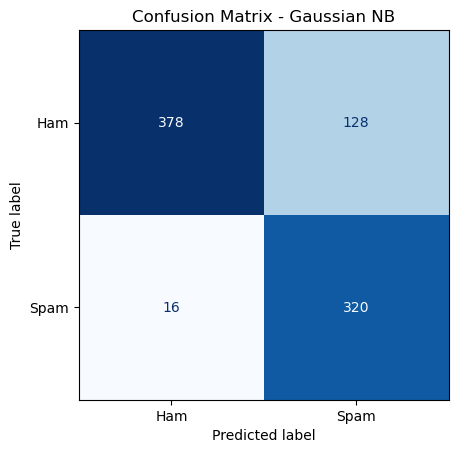

<Figure size 500x400 with 0 Axes>

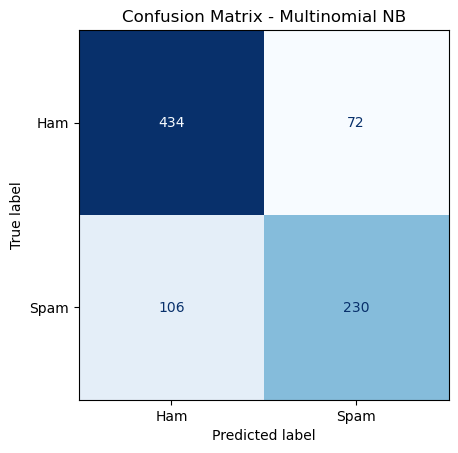

<Figure size 500x400 with 0 Axes>

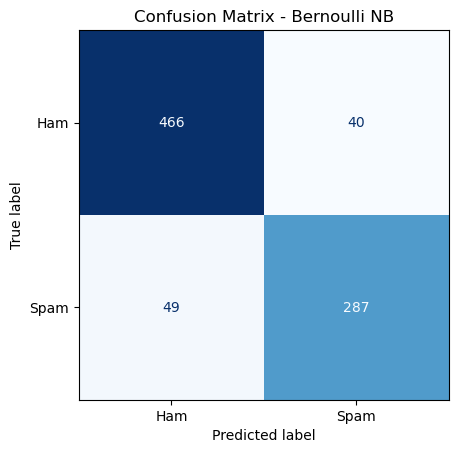

<Figure size 500x400 with 0 Axes>

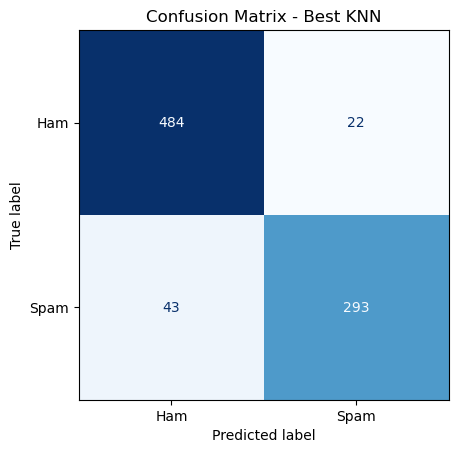

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay


def plot_confusion(result, model_name):

    plt.figure(figsize=(5,4))

    ConfusionMatrixDisplay(
        confusion_matrix=result["Confusion Matrix"],
        display_labels=["Ham", "Spam"]
    ).plot(
        cmap="Blues",
        colorbar=False
    )

    plt.title(f"Confusion Matrix - {model_name}")

    plt.show()

plot_confusion(
    gaussian_results,
    "Gaussian NB"
)

plot_confusion(
    multinomial_results,
    "Multinomial NB"
)

plot_confusion(
    bernoulli_results,
    "Bernoulli NB"
)

plot_confusion(
    best_knn_results,
    "Best KNN"
)

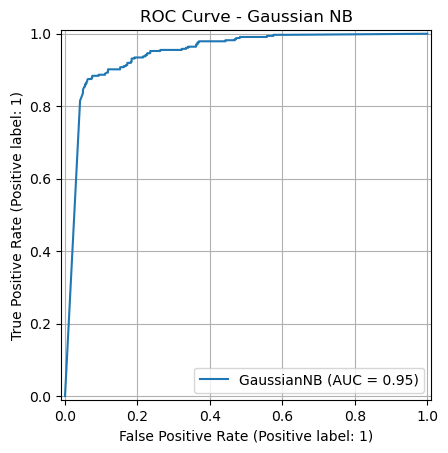

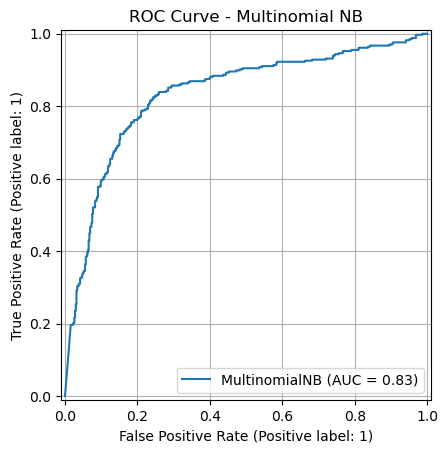

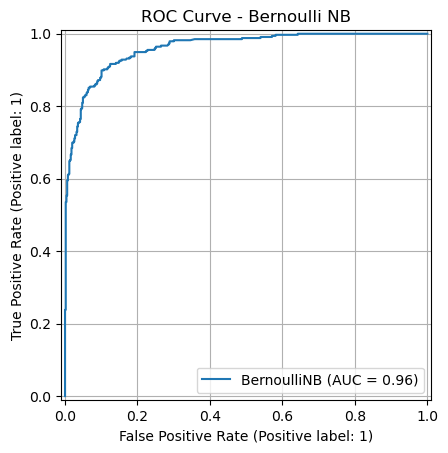

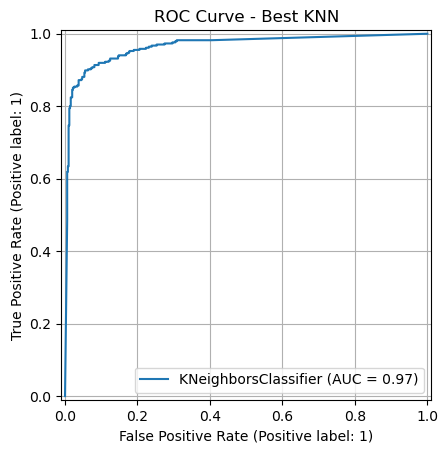

In [15]:
from sklearn.metrics import RocCurveDisplay


def plot_roc(result, X_test, y_test, model_name):

    RocCurveDisplay.from_estimator(
        result["Model"],
        X_test,
        y_test
    )

    plt.title(f"ROC Curve - {model_name}")

    plt.grid(True)

    plt.show()

plot_roc(
    gaussian_results,
    X_test_scaled,
    y_test,
    "Gaussian NB"
)

plot_roc(
    multinomial_results,
    X_test,
    y_test,
    "Multinomial NB"
)

plot_roc(
    bernoulli_results,
    X_test_binary,
    y_test,
    "Bernoulli NB"
)

plot_roc(
    best_knn_results,
    X_test_scaled,
    y_test,
    "Best KNN"
)

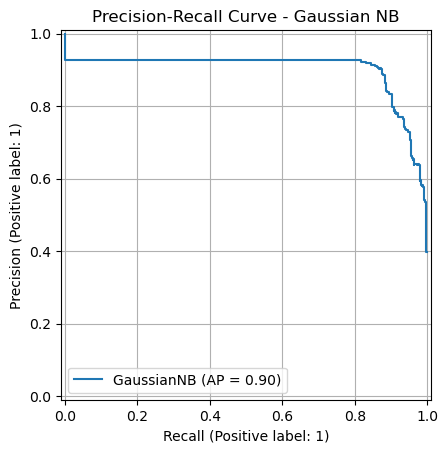

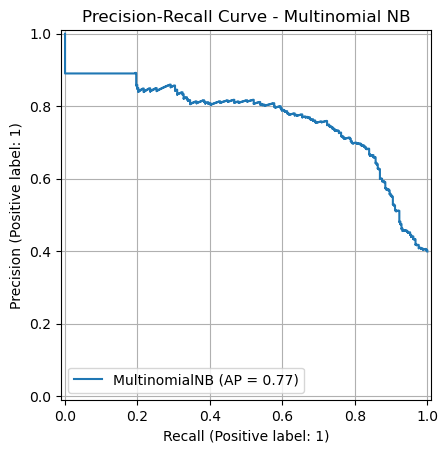

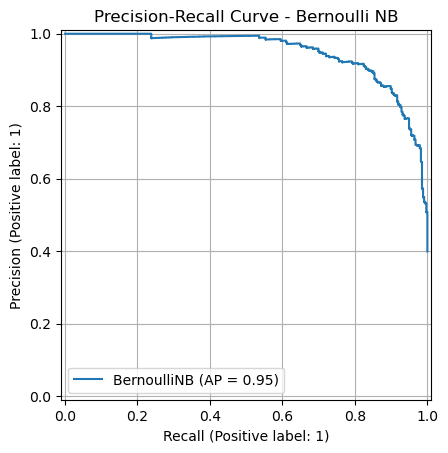

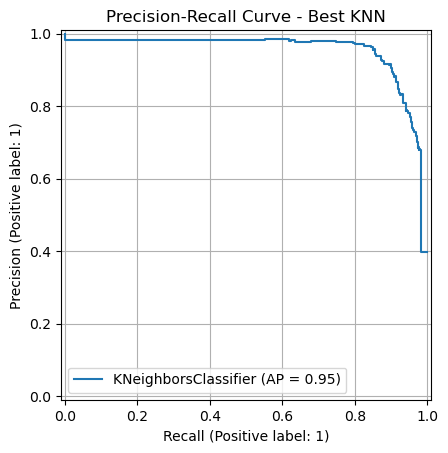

In [16]:
from sklearn.metrics import PrecisionRecallDisplay


def plot_precision_recall(
    result,
    X_test,
    y_test,
    model_name
):

    PrecisionRecallDisplay.from_estimator(
        result["Model"],
        X_test,
        y_test
    )

    plt.title(f"Precision-Recall Curve - {model_name}")

    plt.grid(True)

    plt.show()

plot_precision_recall(
    gaussian_results,
    X_test_scaled,
    y_test,
    "Gaussian NB"
)

plot_precision_recall(
    multinomial_results,
    X_test,
    y_test,
    "Multinomial NB"
)

plot_precision_recall(
    bernoulli_results,
    X_test_binary,
    y_test,
    "Bernoulli NB"
)

plot_precision_recall(
    best_knn_results,
    X_test_scaled,
    y_test,
    "Best KNN"
)

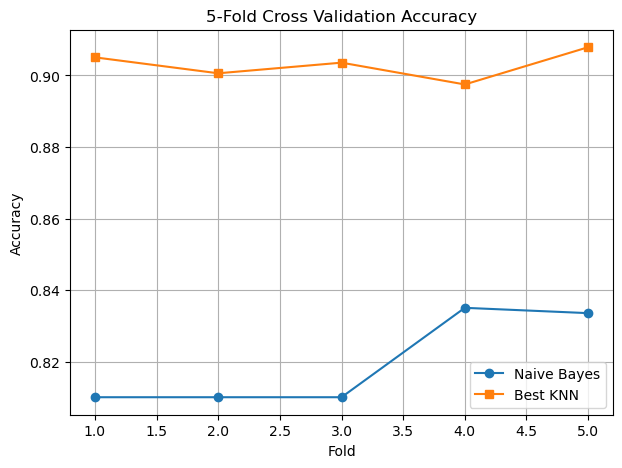

In [17]:
plt.figure(figsize=(7,5))

plt.plot(
    cv_table["Fold"][:-1],
    cv_table["Naive Bayes"][:-1],
    marker="o",
    label="Naive Bayes"
)

plt.plot(
    cv_table["Fold"][:-1],
    cv_table["Best KNN"][:-1],
    marker="s",
    label="Best KNN"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

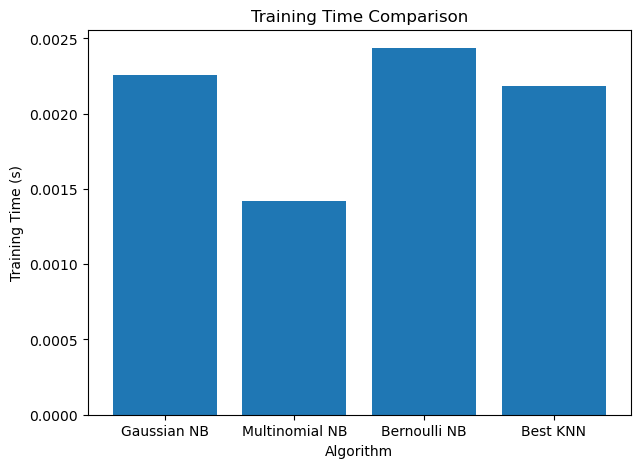

In [18]:
plt.figure(figsize=(7,5))

plt.bar(
    time_table["Algorithm"],
    time_table["Training(s)"]
)

plt.xlabel("Algorithm")
plt.ylabel("Training Time (s)")
plt.title("Training Time Comparison")

plt.show()

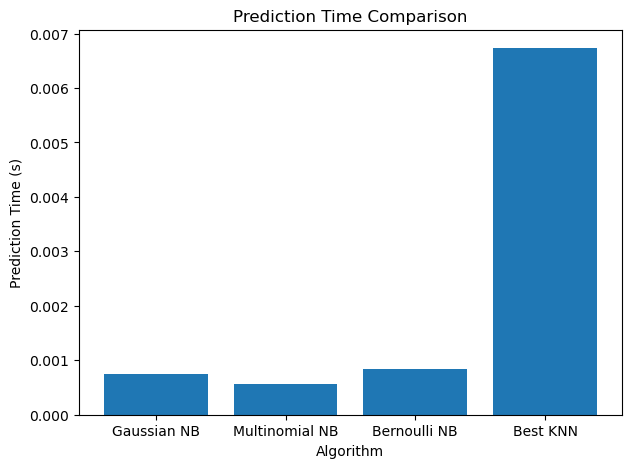

In [19]:
plt.figure(figsize=(7,5))

plt.bar(
    time_table["Algorithm"],
    time_table["Prediction(s)"]
)

plt.xlabel("Algorithm")
plt.ylabel("Prediction Time (s)")
plt.title("Prediction Time Comparison")

plt.show()

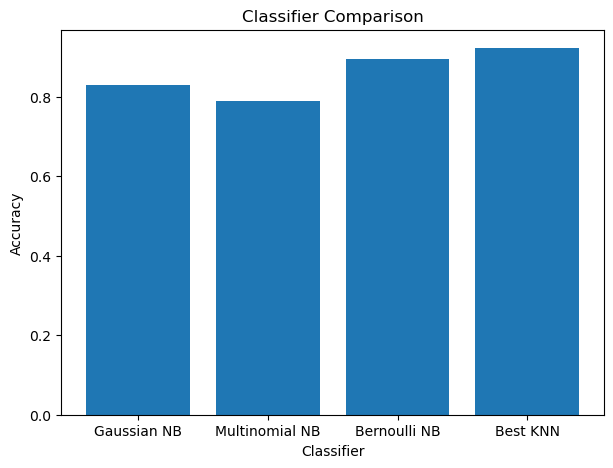

In [20]:
comparison_table = pd.DataFrame({

    "Classifier": [
        "Gaussian NB",
        "Multinomial NB",
        "Bernoulli NB",
        "Best KNN"
    ],

    "Accuracy": [
        gaussian_results["Accuracy"],
        multinomial_results["Accuracy"],
        bernoulli_results["Accuracy"],
        best_knn_results["Accuracy"]
    ]

})

comparison_table

plt.figure(figsize=(7,5))

plt.bar(
    comparison_table["Classifier"],
    comparison_table["Accuracy"]
)

plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.title("Classifier Comparison")

plt.show()

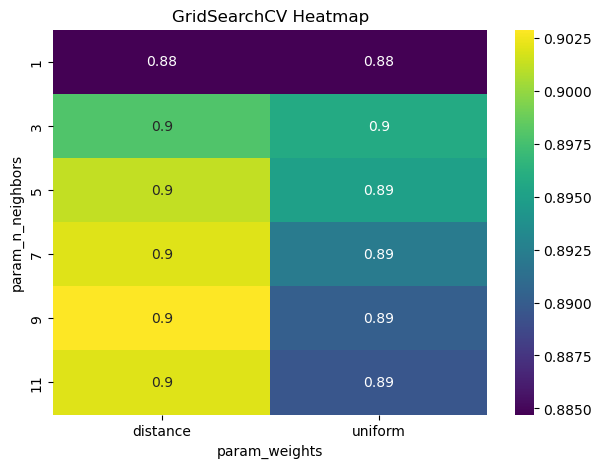

In [21]:
grid_results = pd.DataFrame(grid_search.cv_results_)

pivot_table = grid_results.pivot_table(
    values="mean_test_score",
    index="param_n_neighbors",
    columns="param_weights"
)

plt.figure(figsize=(7,5))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap="viridis"
)

plt.title("GridSearchCV Heatmap")

plt.show()

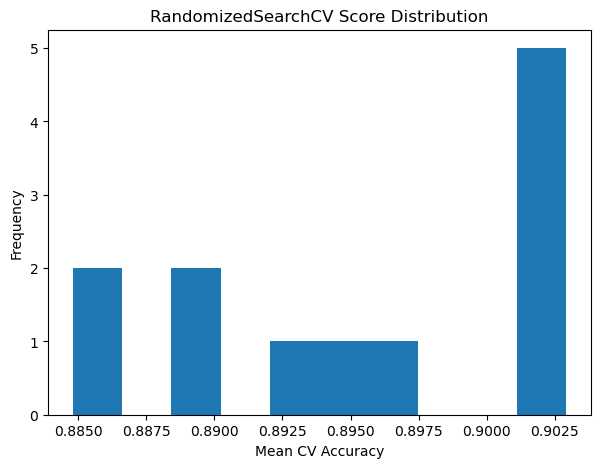

In [22]:
random_results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(7,5))

plt.hist(
    random_results["mean_test_score"],
    bins=10
)

plt.xlabel("Mean CV Accuracy")
plt.ylabel("Frequency")
plt.title("RandomizedSearchCV Score Distribution")

plt.show()